## Confounding in Artificial Intelligence and Machine Learning

c:\Users\Himanshu Saxena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


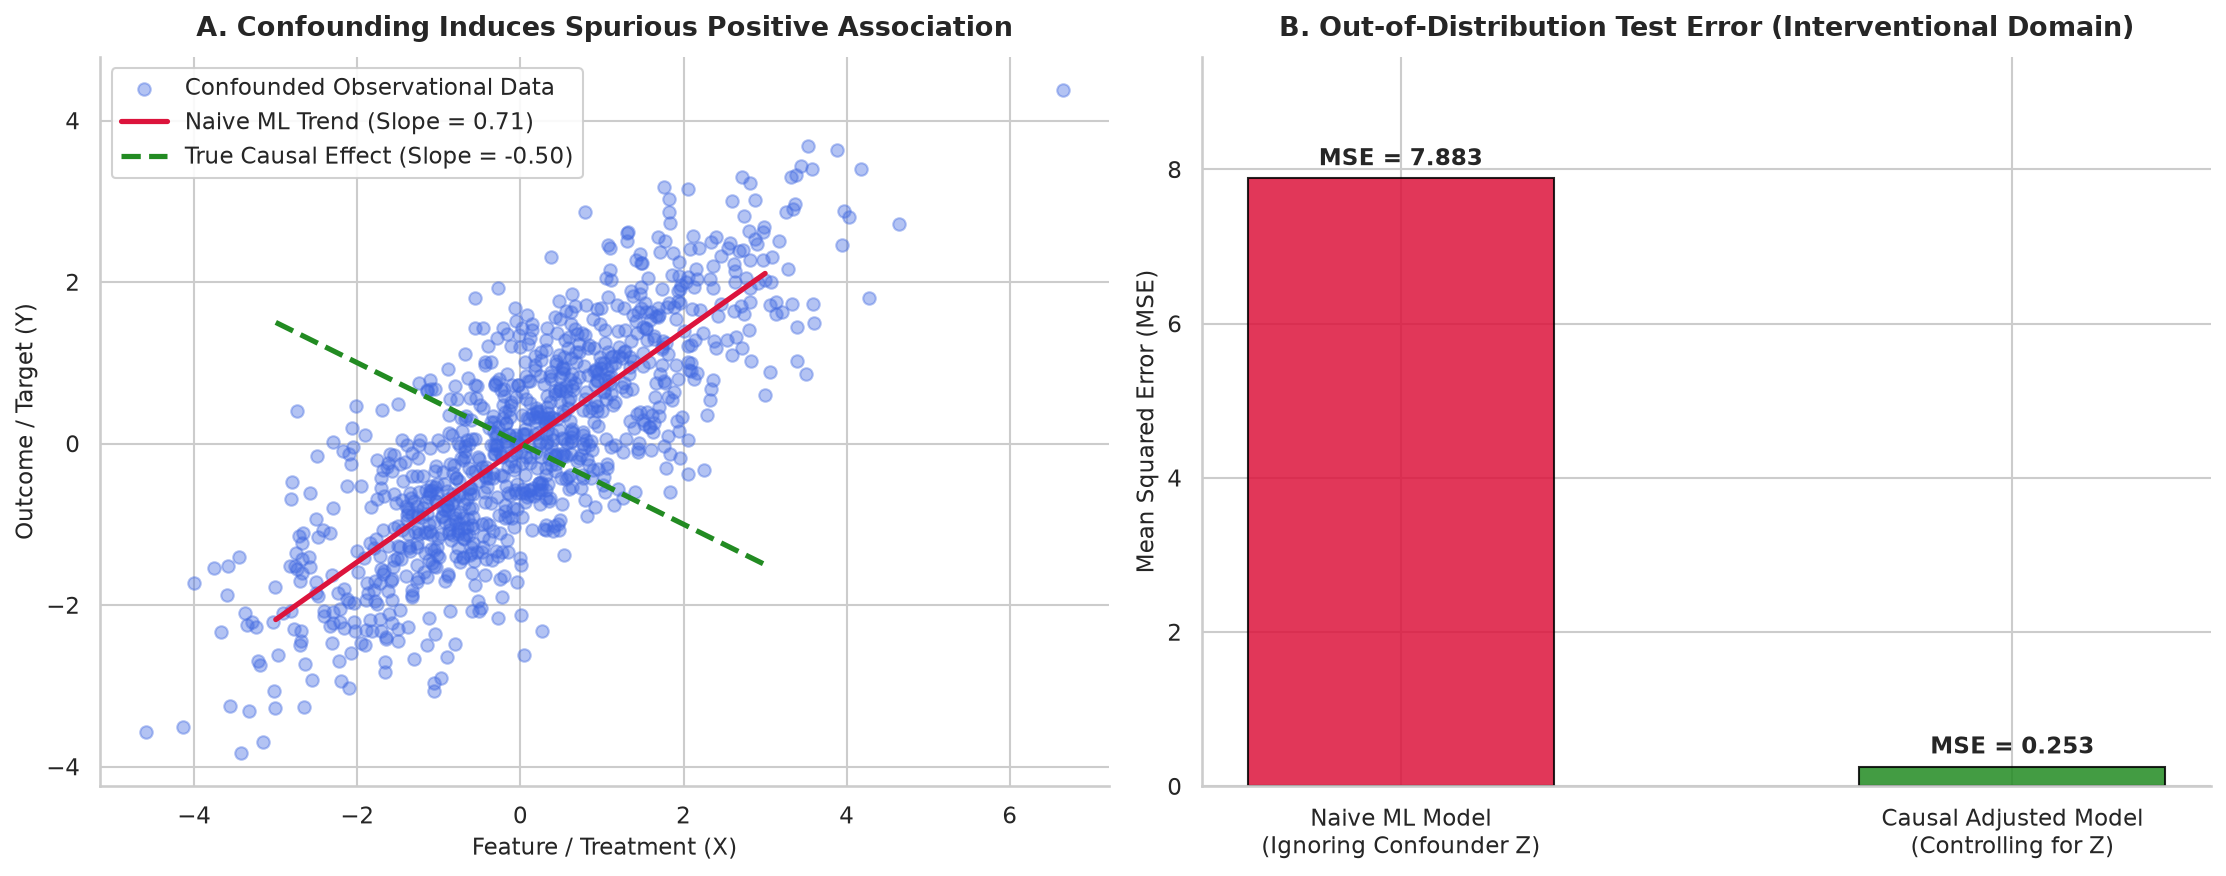

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Set plotting style
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')
plt.rcParams['figure.dpi'] = 150

# 1. Simulate Confounded Data (Source Domain / Observational)
np.random.seed(42)
N = 1000

# Confounder Z (e.g., patient age or disease severity)
Z_obs = np.random.normal(0, 1, N)

# Feature X (treatment, sicker patients are highly likely to receive X)
X_obs = 1.5 * Z_obs + np.random.normal(0, 0.5, N)

# Target Y (True causal effect of X is beneficial / negative, beta = -0.5)
# However, Z acts as a severe positive confounder
Y_obs = -0.5 * X_obs + 2.0 * Z_obs + np.random.normal(0, 0.5, N)

df_obs = pd.DataFrame({'X': X_obs, 'Y': Y_obs, 'Z': Z_obs})

# 2. Simulate Target Domain (Interventional / Out-of-Distribution)
# Interventional domain: X is allocated randomly (Z -> X link broken)
Z_int = np.random.normal(0, 1, N)
X_int = np.random.normal(0, np.std(X_obs), N)
Y_int = -0.5 * X_int + 2.0 * Z_int + np.random.normal(0, 0.5, N)

df_int = pd.DataFrame({'X': X_int, 'Y': Y_int, 'Z': Z_int})

# 3. Fit Models on Observational Data
model_naive = LinearRegression()
model_naive.fit(df_obs[['X']], df_obs['Y'])
coef_naive = model_naive.coef_[0]

model_causal = LinearRegression()
model_causal.fit(df_obs[['X', 'Z']], df_obs['Y'])
coef_causal = model_causal.coef_

# 4. Evaluate OOD Generalization
pred_naive = model_naive.predict(df_int[['X']])
pred_causal = model_causal.predict(df_int[['X', 'Z']])

mse_naive = np.mean((df_int['Y'] - pred_naive)**2)
mse_causal = np.mean((df_int['Y'] - pred_causal)**2)

# 5. Plot Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel A
ax1.scatter(df_obs['X'], df_obs['Y'], alpha=0.4, color='royalblue', label='Confounded Observational Data')
x_vals = np.linspace(-3, 3, 100).reshape(-1, 1)
ax1.plot(x_vals, model_naive.predict(x_vals), color='crimson', linewidth=2.5, 
         label=f"Naive ML Trend (Slope = {coef_naive:.2f})")
ax1.plot(x_vals, -0.5 * x_vals, color='forestgreen', linewidth=2.5, linestyle='--',
         label='True Causal Effect (Slope = -0.50)')
ax1.set_title("A. Confounding Induces Spurious Positive Association", fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel("Feature / Treatment (X)", fontsize=11)
ax1.set_ylabel("Outcome / Target (Y)", fontsize=11)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)

# Panel B
bars = ax2.bar(['Naive ML Model\n(Ignoring Confounder Z)', 'Causal Adjusted Model\n(Controlling for Z)'], 
               [mse_naive, mse_causal], 
               color=['crimson', 'forestgreen'], alpha=0.85, edgecolor='black', width=0.5)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'MSE = {height:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.set_title("B. Out-of-Distribution Test Error (Interventional Domain)", fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel("Mean Squared Error (MSE)", fontsize=11)
ax2.set_ylim(0, max(mse_naive, mse_causal) * 1.2)

sns.despine()
plt.tight_layout()
plt.show()